In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [2]:
df = pd.read_csv("d:/Script/Camilly-Pinheiro/LLM/base_imoveis.csv", sep=',')

df = pd.get_dummies(df, columns=["bairro"], dtype=int)
    
x = df.drop(columns='preco')
y = df["preco"]

In [3]:
X_treino,X_teste,y_treino,y_teste = train_test_split(
    x,
    y,
    test_size=0.3,
    random_state=42
)
#Criando o modelo de regressão linear
modelo = LinearRegression()

#Treinando o modelo
modelo.fit(X_treino,y_treino)

previsoes = modelo.predict(X_teste)

#avaliando o modelo

erro = mean_squared_error(y_teste,previsoes)

resultado = X_teste.copy()

resultado["preco_real"] = y_teste.values
resultado["preco_previsto"] = previsoes
resultado["erro"] = resultado["preco_real"] - resultado["preco_previsto"]

### Gráfico de dispersão


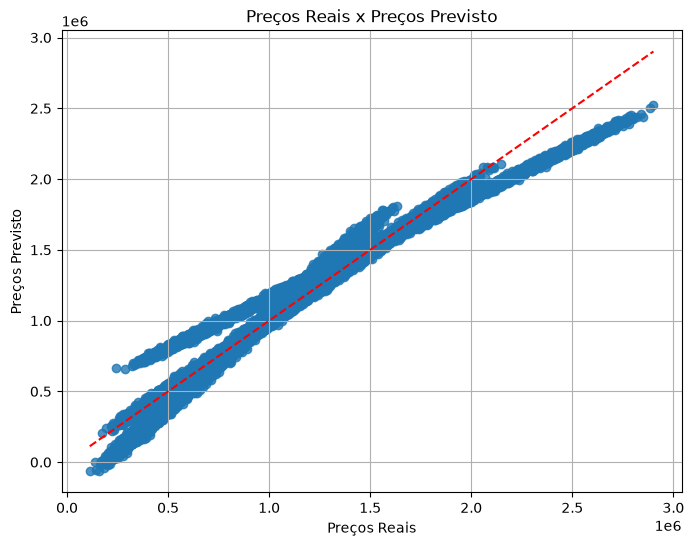

In [4]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_teste,
    previsoes,
    alpha=0.8,
)

plt.plot(
    [y_teste.min(), y_teste.max()],
    [y_teste.min(), y_teste.max()],
    color='red',
    linestyle='--'
)

plt.title("Preços Reais x Preços Previsto")
plt.xlabel("Preços Reais")
plt.ylabel("Preços Previsto")

plt.grid(True)
plt.show()


### Gráfico do erro

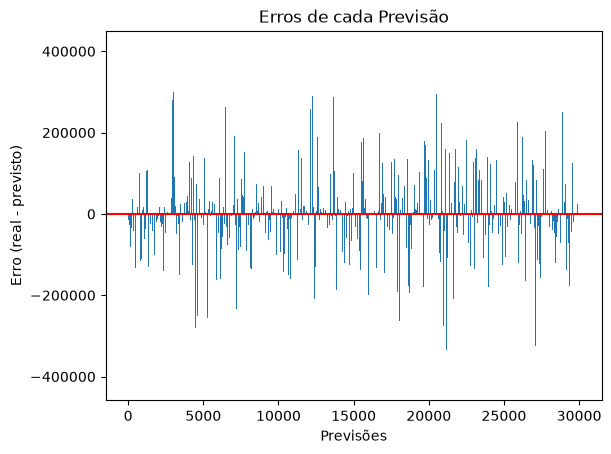

In [5]:
plt.Figure(figsize=(8,5))

plt.bar(
    range(len(resultado)),
    resultado["erro"]
)
plt.axhline(0,color ='red')
plt.title("Erros de cada Previsão")
plt.xlabel("Previsões")
plt.ylabel("Erro (real - previsto)")

plt.show()

### Histograma dos erros

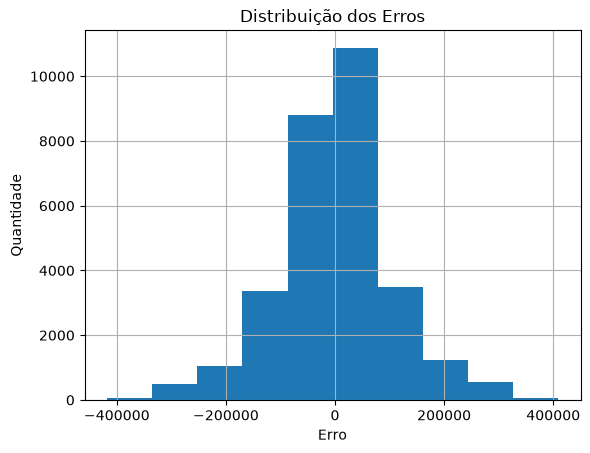

In [6]:
plt.Figure(figsize=(10,5))

plt.hist(resultado['erro'], bins=10)
plt.title("Distribuição dos Erros")
plt.xlabel('Erro')
plt.ylabel('Quantidade')

plt.grid(True)
plt.show()